<a href="https://colab.research.google.com/github/mukterpotom76/EES_lab-mukter/blob/main/EES322_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip -q install -U geemap

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Packages imported successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.1 MB/s eta 0:00:00
Packages imported successfully.


In [3]:
PROJECT_ID = 'ess322-lab1'

ee.Authenticate()
ee.Initialize(project=PROJECT_ID)

print('Earth Engine initialised.')

Earth Engine initialised.


In [4]:
CENTER_LON = 76.9366
CENTER_LAT = 8.5241

centre = ee.Geometry.Point([CENTER_LON, CENTER_LAT])
aoi = centre.buffer(20_000).bounds()  # 20 km buffer, converted to a bounding rectangle
sample_point = centre

print('AOI created.')

AOI created.


In [5]:
START_DATE = '2025-01-01'
END_DATE   = '2025-12-31'
MAX_CLOUD  = 60  # scene-level cloud cover percentage

raw_collection = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .filterBounds(aoi)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.lt('CLOUD_COVER', MAX_CLOUD))
)

scene_count = raw_collection.size().getInfo()
print('Number of matching scenes:', scene_count)

if scene_count == 0:
    raise ValueError('No scenes found. Increase the date range or MAX_CLOUD.')


Number of matching scenes: 32


In [6]:
def preprocess_landsat8(image):
    # QA_PIXEL bits used here:
    # bit 1 = dilated cloud
    # bit 2 = cirrus
    # bit 3 = cloud
    # bit 4 = cloud shadow
    # bit 5 = snow
    qa = image.select('QA_PIXEL')

    clear_mask = (
        qa.bitwiseAnd(1 << 1).eq(0)
        .And(qa.bitwiseAnd(1 << 2).eq(0))
        .And(qa.bitwiseAnd(1 << 3).eq(0))
        .And(qa.bitwiseAnd(1 << 4).eq(0))
        .And(qa.bitwiseAnd(1 << 5).eq(0))
    )

    # Keep pixels that are not radiometrically saturated.
    saturation_mask = image.select('QA_RADSAT').eq(0)

    # Apply official Collection 2 scaling to optical surface-reflectance bands.
    optical = image.select('SR_B[1-7]').multiply(0.0000275).add(-0.2)

    return (
        image.addBands(optical, None, True)
        .updateMask(clear_mask)
        .updateMask(saturation_mask)
    )

# Choose the least-cloudy matching scene, then preprocess it.
raw_image = ee.Image(raw_collection.sort('CLOUD_COVER').first())
image = preprocess_landsat8(raw_image)

print('Product ID:', raw_image.get('LANDSAT_PRODUCT_ID').getInfo())
print('Acquisition date:', raw_image.date().format('YYYY-MM-dd').getInfo())
print('Scene cloud cover (%):', raw_image.get('CLOUD_COVER').getInfo())


Product ID: LC08_L2SP_144054_20250225_20250304_02_T1
Acquisition date: 2025-02-25
Scene cloud cover (%): 0.48


In [7]:
Map = geemap.Map()
Map.centerObject(aoi, 10)

# True colour: Red, Green, Blue = B4, B3, B2
true_color = {
    'bands': ['SR_B4', 'SR_B3', 'SR_B2'],
    'min': 0.0,
    'max': 0.30,
}

# Colour infrared: NIR, Red, Green = B5, B4, B3
false_color = {
    'bands': ['SR_B5', 'SR_B4', 'SR_B3'],
    'min': 0.0,
    'max': 0.35,
}

Map.addLayer(image.clip(aoi), true_color, 'True colour (4-3-2)')
Map.addLayer(image.clip(aoi), false_color, 'False colour (5-4-3)', False)
Map.addLayer(aoi, {'color': 'yellow'}, 'AOI', False)
Map.addLayer(sample_point, {'color': 'red'}, 'Sample point')
Map


Map(center=[8.524120270793116, 76.93689615892917], controls=(WidgetControl(options=['position', 'transparent_b…

In [8]:
band_names = [
    ('SR_B1', 'Coastal aerosol'),
    ('SR_B2', 'Blue'),
    ('SR_B3', 'Green'),
    ('SR_B4', 'Red'),
    ('SR_B5', 'NIR'),
    ('SR_B6', 'SWIR1'),
    ('SR_B7', 'SWIR2'),
]

BandMap = geemap.Map()
BandMap.centerObject(aoi, 10)

for band, label in band_names:
    BandMap.addLayer(
        image.select(band).clip(aoi),
        {'min': 0.0, 'max': 0.35},
        label,
        False,
    )

# Show the red band by default.
BandMap.addLayer(image.select('SR_B4').clip(aoi), {'min': 0.0, 'max': 0.35}, 'Red - active')
BandMap.addLayer(sample_point, {'color': 'red'}, 'Sample point')
BandMap


Map(center=[8.524120270793116, 76.93689615892917], controls=(WidgetControl(options=['position', 'transparent_b…

In [9]:
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']

# Approximate band-centre wavelengths in micrometres.
wavelength_um = [0.443, 0.482, 0.562, 0.655, 0.865, 1.609, 2.201]

sample_area = sample_point.buffer(45)

spectrum = (
    image.select(bands)
    .reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=sample_area,
        scale=30,
        maxPixels=1_000_000,
    )
    .getInfo()
)

reflectance = [spectrum.get(b, np.nan) for b in bands]

spectral_table = pd.DataFrame({
    'Band': bands,
    'Wavelength_um': wavelength_um,
    'Surface_reflectance': reflectance,
})

spectral_table


,Band,Wavelength_um,Surface_reflectance
0,SR_B1,0.443,0.068378
1,SR_B2,0.482,0.074204
2,SR_B3,0.562,0.090684
3,SR_B4,0.655,0.104069
4,SR_B5,0.865,0.207413
5,SR_B6,1.609,0.212124
6,SR_B7,2.201,0.155413


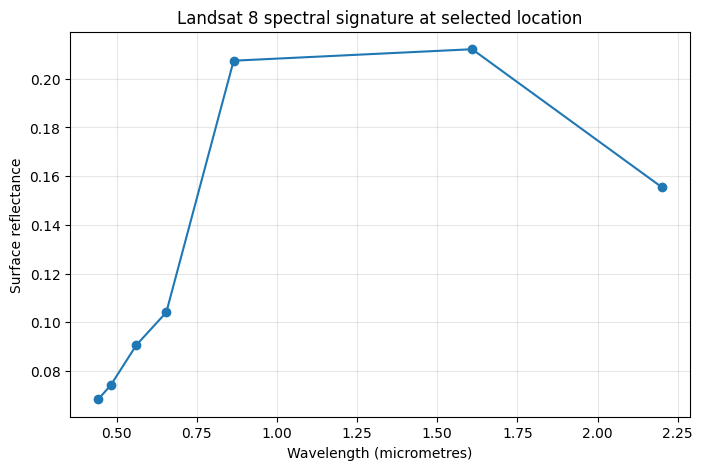

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(wavelength_um, reflectance, marker='o')
plt.xlabel('Wavelength (micrometres)')
plt.ylabel('Surface reflectance')
plt.title('Landsat 8 spectral signature at selected location')
plt.grid(True, alpha=0.3)
plt.show()